In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(
    openai_api_base="https://openrouter.ai/api/v1",
    model="openrouter/free"
)

In [4]:
class ChatState(TypedDict):
    messages: Annotated[list[str], add_messages]

In [5]:
def chat(state: ChatState):
    messages = state["messages"]

    response = model.invoke(messages)

    return {"messages": [response]}

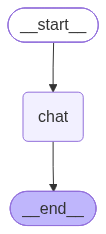

In [6]:
graph = StateGraph(ChatState)

graph.add_node("chat", chat)

graph.add_edge(START, "chat")
graph.add_edge("chat", END)

checkpointer = InMemorySaver()

chatbot = graph.compile(checkpointer=checkpointer)
chatbot

In [14]:
thread_id = 1

while True:
    user_message = input("Type here: ")
    print(f"\nUser: {user_message}")

    if user_message.strip().lower() in ["exit", "bye", "quit"]:
        break

    config = {"configurable": {"thread_id": thread_id}}

    print("AI: ", end="")

    for message_chunk, metadata in chatbot.stream(
        {"messages": [HumanMessage(content=user_message)]},
        config=config,
        stream_mode="messages"
    ):
        if message_chunk.content:
            print(message_chunk.content, end="", flush=True)

    print("\n")


User: hello
AI: Hello! How can I help you today?


User: what is my name
AI: Your name is **Hamza**! 😊 How can I help you today?


User: write a 200 words post on global warmiing
AI: **Global Warming: A Silent Crisis We Can No Longer Ignore**

Global warming refers to the long‑term rise in Earth’s average temperature, driven largely by human activities that increase greenhouse gases such as carbon dioxide, methane, and nitrous oxide. Since the Industrial Revolution, temperatures have climbed about 1.2 °C, altering weather patterns, melting polar ice caps, and raising sea levels. The consequences are stark: more frequent heatwaves, intensified storms, droughts that cripple agriculture, and the spread of vector‑borne diseases. Coastal cities face inundation, while ecosystems from coral reefs to Arctic habitats suffer irreversible loss.

Addressing global warming demands swift, coordinated action. Transitioning to renewable energy, improving energy efficiency, and protecting forests can 

In [8]:
chatbot.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='176e51c3-85f9-4921-a586-8a225ae60a47'), AIMessage(content='Hi! How can I help you today?', additional_kwargs={}, response_metadata={'finish_reason': 'stopstop', 'model_name': 'nex-agi/nex-n2.5-mini:freenex-agi/nex-n2.5-mini:free', 'model_provider': 'openai'}, id='lc_run--01a0d6a6-2544-7d51-a5f3-e1c3c44fc8c0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 10, 'output_tokens': 13, 'total_tokens': 23, 'input_token_details': {'audio': 0, 'cache_creation': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 1}}), HumanMessage(content='write me a blog on the topic of education in pakistan', additional_kwargs={}, response_metadata={}, id='72ff5bd2-c8e6-4697-bc3c-22ea65de9107'), AIMessage(content='**Education in Pakistan: Challenges, Opportunities, and the Road Ahead**\n\n*By [Your Name]*  \n*Date: [Insert Date]*  \n\n---\n\n### Introduction  